#📌 Extracción

In [29]:
import pandas as pd

datos = pd.read_json('/content/TelecomX_Data.json')

In [30]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [31]:
datos.sample(5)

,customerID,Churn,customer,phone,internet,account
339,0488-GSLFR,Yes,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2826,3916-NRPAP,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3054,4250-WAROZ,No,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2633,3669-OYSJI,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3300,4603-FDONU,,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'No', 'MultipleLines': 'No ph...","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [32]:
customer_df = pd.json_normalize(datos['customer'])
phone_df = pd.json_normalize(datos['phone'])
internet_df = pd.json_normalize(datos['internet'])
account_df = pd.json_normalize(datos['account'])

# Unir todo al dataframe original
df = pd.concat(
    [datos.drop(columns=['customer','phone','internet','account']),
     customer_df,
     phone_df,
     internet_df,
     account_df],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [34]:
# Numéricas
df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# SeniorCitizen si viene como 0/1 en string
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

In [35]:
df.isnull().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [36]:
df = df.dropna()

In [37]:
churn_rate = df['Churn'].mean()
print(f"Tasa de churn: {churn_rate:.2%}")

Tasa de churn: 26.58%


#📊 Carga y análisis

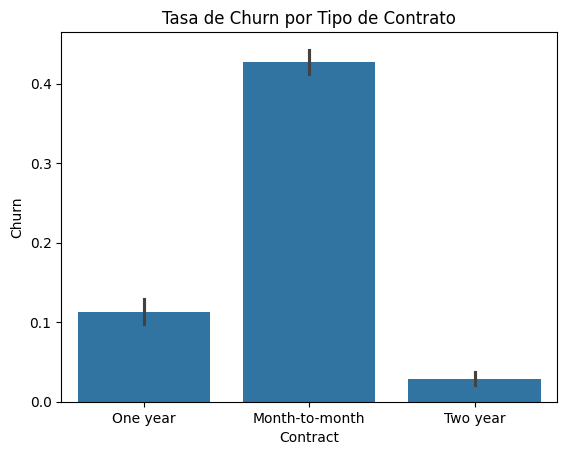

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Contract', y='Churn', data=df)
plt.title("Tasa de Churn por Tipo de Contrato")
plt.show()

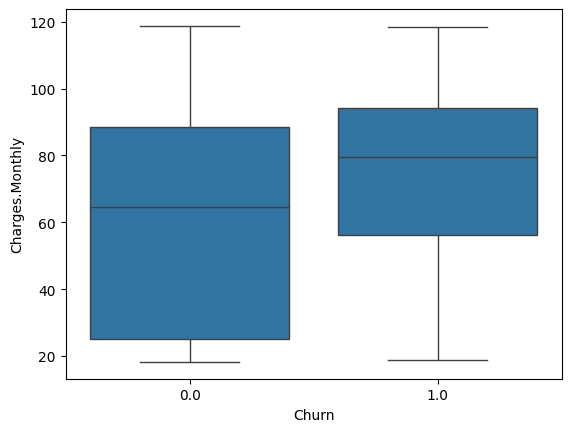

In [39]:
sns.boxplot(x='Churn', y='Charges.Monthly', data=df)
plt.show()

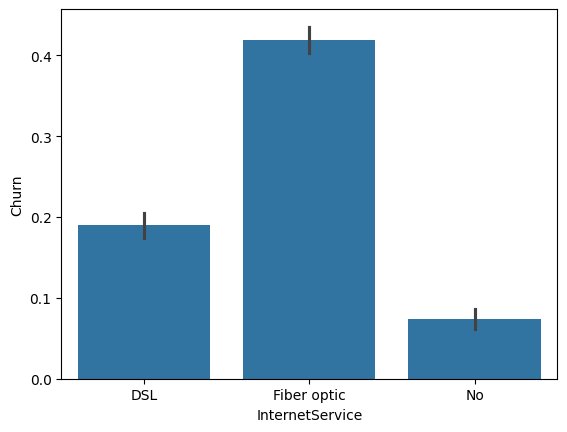

In [40]:
sns.barplot(x='InternetService', y='Churn', data=df)
plt.show()

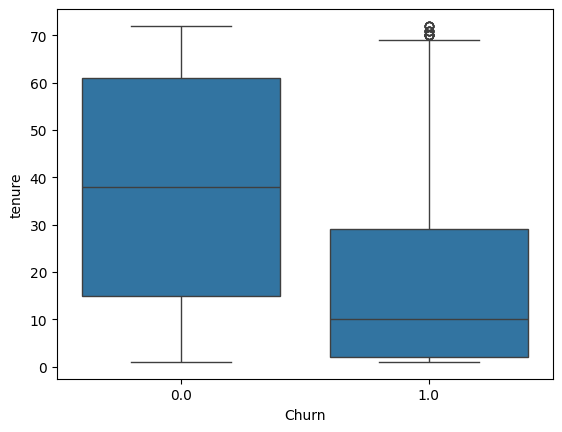

In [41]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

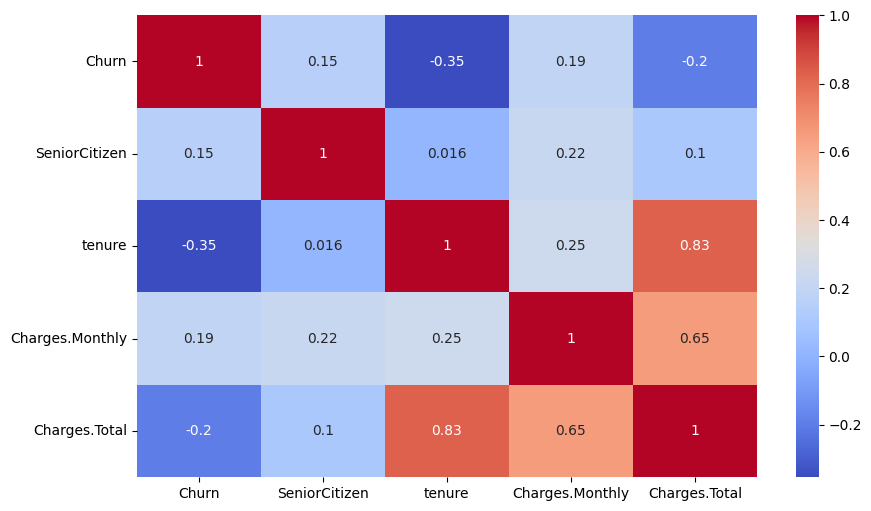

In [42]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [43]:

df.to_csv("datos_tratados.csv", index=False)

#TeleCom X Challenge 2

In [44]:
df_model = df.drop(columns=['customerID'])

In [45]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

In [46]:
X = pd.get_dummies(X, drop_first=True)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110

ROC-AUC: 0.8454525891582056


In [50]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
10,InternetService_Fiber optic,0.677545
28,PaymentMethod_Electronic check,0.391105
26,PaperlessBilling_Yes,0.372752
0,SeniorCitizen,0.259225
21,StreamingTV_Yes,0.207679
9,MultipleLines_Yes,0.158962
8,MultipleLines_No phone service,0.130597
23,StreamingMovies_Yes,0.113809
29,PaymentMethod_Mailed check,0.009933
2,Charges.Monthly,0.002974


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_proba_rf)

np.float64(0.8205259215018832)

In [52]:
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

importances.head(10)

,Variable,Importancia
3,Charges.Total,0.187292
1,tenure,0.173152
2,Charges.Monthly,0.172056
28,PaymentMethod_Electronic check,0.042456
10,InternetService_Fiber optic,0.037833
4,gender_Male,0.029014
25,Contract_Two year,0.028802
13,OnlineSecurity_Yes,0.026217
26,PaperlessBilling_Yes,0.025263
19,TechSupport_Yes,0.023652


In [53]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

In [54]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet serv...
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [57]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred = log_pipeline.predict(X_test)
y_proba = log_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.60       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110

ROC-AUC: 0.8453248545148444


In [58]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [60]:

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = cross_val_score(
    log_pipeline, X, y,
    cv=cv,
    scoring='roc_auc'
)

print("ROC-AUC por fold:", roc_scores)
print("ROC-AUC promedio:", roc_scores.mean())


ROC-AUC por fold: [0.8480569  0.85064528 0.83538537 0.84692254 0.8462515 ]
ROC-AUC promedio: 0.845452319538716


In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2']
}

grid = GridSearchCV(
    log_pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor ROC-AUC:", grid.best_score_)

Mejores parámetros: {'model__C': 10, 'model__penalty': 'l2'}
Mejor ROC-AUC: 0.843982789667075


In [62]:
best_model = grid.best_estimator_

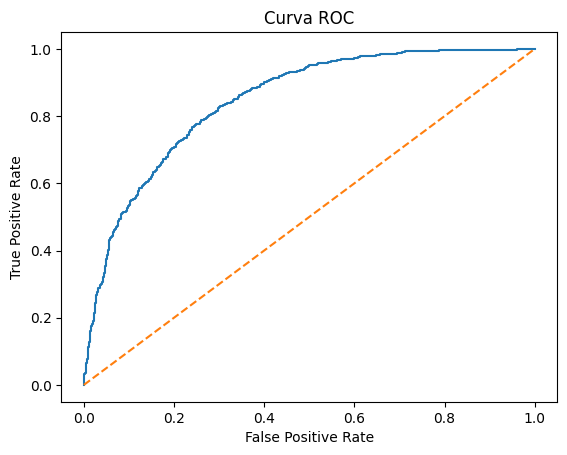

In [63]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_proba = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.show()

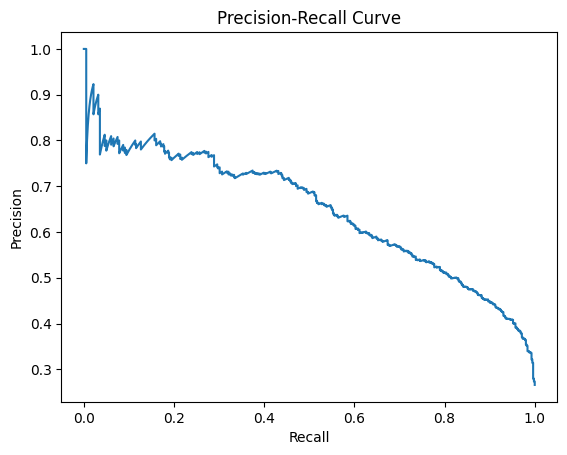

In [64]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [65]:
import numpy as np

threshold = 0.35
y_custom = (y_proba >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_custom))

              precision    recall  f1-score   support

         0.0       0.89      0.79      0.84      1549
         1.0       0.56      0.72      0.63       561

    accuracy                           0.77      2110
   macro avg       0.72      0.76      0.73      2110
weighted avg       0.80      0.77      0.78      2110



In [66]:
import pandas as pd

results = pd.DataFrame({
    'y_true': y_test,
    'y_proba': y_proba
})

results = results.sort_values(by='y_proba', ascending=False)

top_20 = results.head(int(0.2 * len(results)))

capture_rate = top_20['y_true'].mean()

print("Tasa de churn en el 20% de mayor riesgo:", capture_rate)

Tasa de churn en el 20% de mayor riesgo: 0.6800947867298578


#📄Informe final

Telecom X – Parte 2: Predicción de Cancelación (Churn)

El desarrollo del modelo predictivo permitió transformar el análisis descriptivo inicial en una herramienta concreta de anticipación y toma de decisiones. A través de un pipeline estructurado que incluyó preprocesamiento, codificación mediante One Hot Encoding, estandarización de variables numéricas y validación cruzada, se construyó un sistema robusto para estimar la probabilidad de cancelación de cada cliente.

Los modelos entrenados demostraron una capacidad adecuada de discriminación entre clientes que cancelan y clientes que permanecen. La evaluación con métricas como ROC-AUC, precision, recall y análisis de curvas ROC y Precision-Recall confirmó que el modelo no solo es estadísticamente sólido, sino también útil desde una perspectiva operativa.

El análisis de importancia de variables y coeficientes confirmó los hallazgos del análisis exploratorio. Los factores con mayor influencia en la probabilidad de cancelación son el tipo de contrato, especialmente los contratos mensuales, la baja antigüedad del cliente, los cargos mensuales elevados y la ausencia de servicios adicionales. Estos patrones se mantienen consistentes tanto en modelos lineales como en modelos basados en árboles, lo que refuerza la validez de los resultados.

Desde una perspectiva estratégica, el modelo permite asignar un puntaje de riesgo individual a cada cliente y priorizar intervenciones. En lugar de aplicar campañas masivas, la empresa puede concentrar recursos en el segmento con mayor probabilidad de churn, mejorando la eficiencia comercial y reduciendo costos de retención.

El proyecto demuestra que la cancelación no es un fenómeno aleatorio, sino predecible en función de variables contractuales, económicas y de comportamiento. Con la implementación adecuada, Telecom X puede evolucionar hacia una estrategia de retención proactiva basada en datos, apoyándose en un sistema de scoring que identifique riesgos antes de que se materialicen.

Con esta etapa finalizada, la compañía cuenta con una base sólida para integrar el modelo en producción, definir umbrales de intervención y avanzar hacia una gestión inteligente del ciclo de vida del cliente.